
矩阵 A = 
[[0.8 0.1]
 [0.2 0.7]]
特征值: [0.9+0.j 0.6+0.j]
|λ|: [0.9 0.6]
稳定性: ✅ stable (convergence)

矩阵 A = 
[[1.2 0.1]
 [0.2 1.1]]
特征值: [1.3+0.j 1. +0.j]
|λ|: [1.3 1. ]
稳定性: ❌ unstable (divergence)

矩阵 A = 
[[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]
特征值: [0.8660254+0.5j 0.8660254-0.5j]
|λ|: [1. 1.]
稳定性: ⚠️ critical stability (may oscillate or not decay)


C:\Users\15086\AppData\Local\Temp\ipykernel_28504\1442070871.py:74: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\15086\AppData\Local\Temp\ipykernel_28504\1442070871.py:74: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


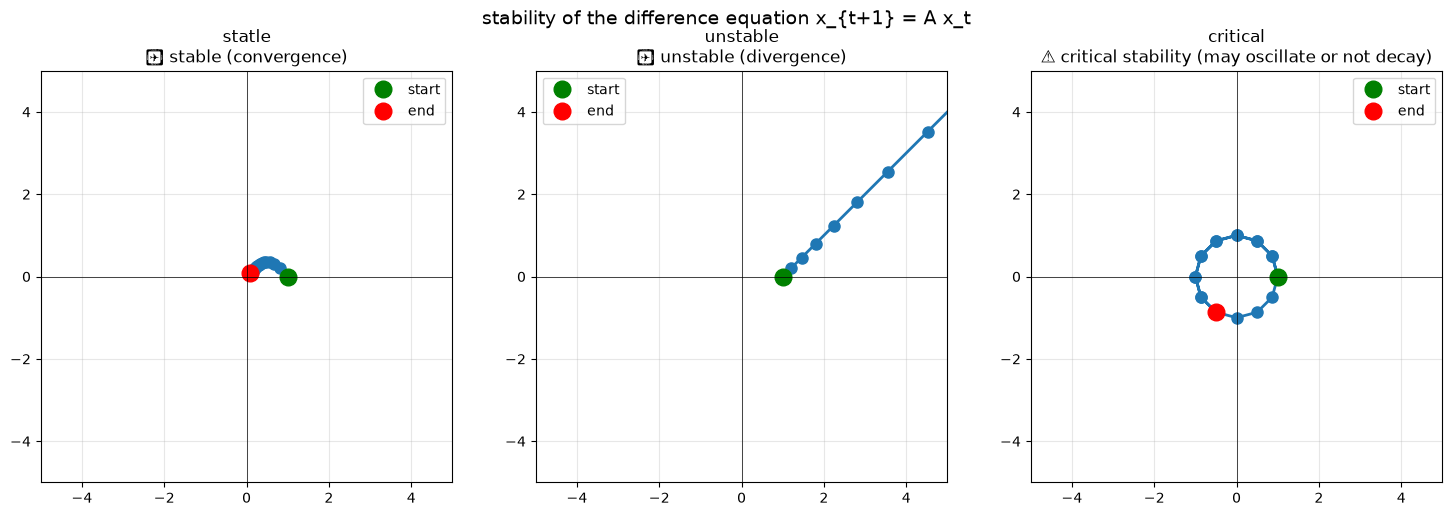

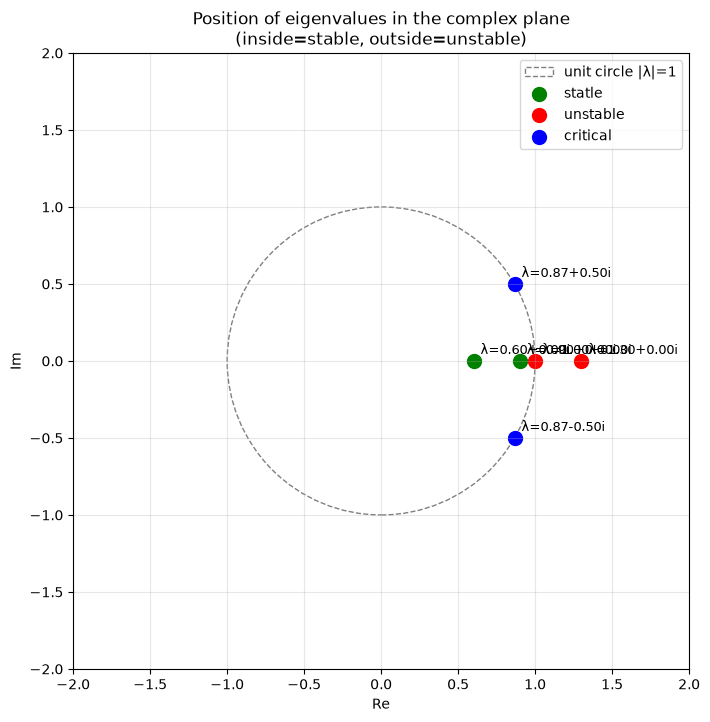

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_system(A, x0, steps=20):
    """分析差分方程 x_{t+1} = A x_t 的稳定性"""
    eigenvalues = np.linalg.eigvals(A)
    
    print("\n" + "=" * 60)
    print(f"矩阵 A = \n{A}")
    print(f"特征值: {eigenvalues}")
    print(f"|λ|: {np.abs(eigenvalues)}")
    
    # 稳定性判断
    if np.all(np.abs(eigenvalues) < 1):
        stability = "✅ stable (convergence)"
    elif np.any(np.abs(eigenvalues) > 1):
        stability = "❌ unstable (divergence)"
    else:
        # stability = "⚠️ 临界稳定（可能振荡或不衰减）"
        stability = "⚠️ critical stability (may oscillate or not decay)"
    print(f"稳定性: {stability}")
    
    # 模拟演化
    x = x0.copy()
    trajectory = [x.copy()]
    for _ in range(steps):
        x = A @ x
        trajectory.append(x.copy())
    trajectory = np.array(trajectory)
    
    return trajectory, stability

# ---- 三个典型的矩阵 ----
# 1. 稳定矩阵：|λ| < 1
A_stable = np.array([[0.8, 0.1], [0.2, 0.7]])
# 2. 不稳定矩阵：有 |λ| > 1
A_unstable = np.array([[1.2, 0.1], [0.2, 1.1]])
# 3. 临界稳定：|λ| = 1（旋转矩阵）
theta = np.pi / 6
A_critical = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])

x0 = np.array([1, 0])

# ---- 分析每个系统 ----
systems = [
    ("statle", A_stable),
    ("unstable", A_unstable),
    ("critical", A_critical)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, A) in enumerate(systems):
    trajectory, stability = analyze_system(A, x0, steps=20)
    
    ax = axes[idx]
    # 轨迹
    ax.plot(trajectory[:, 0], trajectory[:, 1], 'o-', linewidth=2, markersize=8)
    ax.plot(trajectory[0, 0], trajectory[0, 1], 'go', markersize=12, label='start')
    ax.plot(trajectory[-1, 0], trajectory[-1, 1], 'ro', markersize=12, label='end')
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_title(f"{name}\n{stability}")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

# plt.suptitle('差分方程 x_{t+1} = A x_t 的稳定性', fontsize=14)
plt.suptitle('stability of the difference equation x_{t+1} = A x_t', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 特征值在复平面上的位置 ----
plt.figure(figsize=(10, 8))
unit_circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray', label='unit circle |λ|=1')
plt.gca().add_artist(unit_circle)

colors = ['green', 'red', 'blue']
for idx, (name, A) in enumerate(systems):
    eigvals = np.linalg.eigvals(A)
    plt.scatter(np.real(eigvals), np.imag(eigvals), 
               s=100, color=colors[idx], label=name)
    # 添加标签
    for ev in eigvals:
        plt.annotate(f'λ={ev.real:.2f}{ev.imag:+.2f}i', 
                    xy=(ev.real, ev.imag), xytext=(5, 5),
                    textcoords='offset points', fontsize=9)

plt.xlabel('Re')
plt.ylabel('Im')
# plt.title('特征值在复平面上的位置\n（单位圆内=稳定，外=不稳定）')
plt.title('Position of eigenvalues in the complex plane\n(inside=stable, outside=unstable)')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()